# AI 辅助编程与可靠的数字识别实验

机器学习第 2 章 · 教师演示与学生课后练习原型

## 目标（Goal）
用 scikit-learn 的 digits 数据完成基线、数据划分、验证选参和错误分析。你需要说明代码为什么这样写，而不只是让 AI 帮你运行。

课堂只演示数据、划分与基线；验证选参和错例部分可课后继续，第 4 讲再深入。

**实验约定**：固定种子 42；约 60/20/20 训练/验证/测试；只在训练数据上拟合预处理；选参只看验证集；方案冻结后一次报告测试结果。

**数据卡**：`sklearn.datasets.load_digits`，1797 个样本、64 个特征（8×8 灰度像素）、10 类。随库提供，运行时不下载。它不是 MNIST；随机分层划分只演示同源样本评估，不能证明对新书写者或手机照片有效。来源与原始数据说明见 [scikit-learn digits 文档](https://scikit-learn.org/stable/datasets/toy_dataset.html#optical-recognition-of-handwritten-digits-dataset)。本 Notebook 不另打包数据副本。

代码为本项目编写；方法参考 [Common pitfalls](https://scikit-learn.org/stable/common_pitfalls.html) 与 [模型选择示例](https://scikit-learn.org/stable/auto_examples/model_selection/plot_grid_search_digits.html)，核查日期 2026-09-05。


## 怎样使用这份实验

课堂主线：步骤1—10（约30分钟）；步骤11—15建立预处理与模型直觉（约20分钟）；步骤16以后为课后延伸，第4讲回访。每步先回答问题，再按 Shift+Enter；不要一开始就运行全部代码。

教学结构参考 [INRIA：逐步拆解预处理](https://inria.github.io/scikit-learn-mooc/python_scripts/02_numerical_pipeline_scaling.html)。先观察 `fit` 学到了什么，再理解 `transform` 与 Pipeline；本课数据与计算由课程编排，非该上游案例逐字复制。

## 步骤1｜确认我们使用哪套工具

NumPy保存数组；sklearn提供模型；Matplotlib负责画图。先只导入这一步需要的工具，其余到用时再引入。

<strong>先想一想：</strong> 固定种子能让模型在所有新数据上同样准确吗？

<!-- [ref:l2-env-check] -->

In [1]:
%matplotlib inline
import sys, time
import numpy as np
import sklearn
import matplotlib
import matplotlib.pyplot as plt
SEED = 42
print("Python", sys.version.split()[0], "sklearn", sklearn.__version__)

Python 3.14.6 sklearn 1.9.0


<strong>运行后看哪里：</strong> 打印实际环境版本。固定种子让后面的划分可复现。

<details><summary>展开检查答案</summary>

不能。它固定随机过程，不证明泛化。

</details>

## 步骤2｜一行数据代表什么？

输入特征（Feature）记为X，真实标签（Label）记为y；两者必须逐行对应。

<strong>先想一想：</strong> 为什么不是64个样本、1797个特征？

<!-- [ref:l2-load-digits] -->

In [2]:
from sklearn.datasets import load_digits
digits = load_digits()
X, y = digits.data, digits.target
print("样本数、特征数：", X.shape)
print("类别：", np.unique(y))
assert X.shape == (1797, 64)
assert np.isfinite(X).all()

样本数、特征数： (1797, 64)
类别： [0 1 2 3 4 5 6 7 8 9]


<strong>运行后看哪里：</strong> 1797行样本，每行64个像素；类别为0到9。

<details><summary>展开检查答案</summary>

sklearn约定X的第0维是样本，第1维是特征；y与X行数一致。

</details>

## 步骤3｜把64个数字还原成图像

先看一个样本，而不是同时看数据处理与模型。reshape改变排列形状，不改变像素值。

<strong>先想一想：</strong> reshape(8,8)有没有生成新的训练样本？

向量形状： (64,) 真实标签： 0


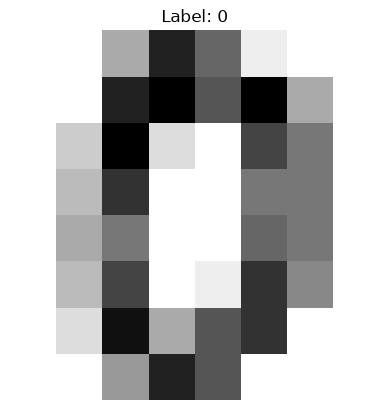

In [3]:
sample = X[0]
print("向量形状：", sample.shape, "真实标签：", y[0])
plt.imshow(sample.reshape(8, 8), cmap="gray_r")
plt.title(f"Label: {y[0]}")
plt.axis("off")
plt.show()

<strong>运行后看哪里：</strong> Label为真实标签；灰度图展示同一个64维输入。

<details><summary>展开检查答案</summary>

没有。它把同一行的64项按8行8列显示。

</details>

## 步骤4｜为什么先保留测试集？

我们最终想检查未参与模型选择的样本。此处划分行索引，方便检查重叠，不立即拿测试集试模型。

<strong>先想一想：</strong> 为什么这里传入indices而不是直接传X？

<!-- [ref:l2-split-test] -->

In [4]:
from sklearn.model_selection import train_test_split
indices = np.arange(len(y))
dev_idx, test_idx = train_test_split(
    indices, test_size=0.2, stratify=y, random_state=SEED)
print("开发集：", len(dev_idx), "测试集：", len(test_idx))

开发集： 1437 测试集： 360


<strong>运行后看哪里：</strong> 开发集1437，测试集360。stratify让各类别比例接近。

<details><summary>展开检查答案</summary>

保留样本身份便于审计；同样的索引能同时提取X与y。

</details>

## 步骤5｜开发集再分成训练与验证

训练集学习参数；验证集选择配置。剩余80%中的25%是总体20%，因此最终约60/20/20。

<strong>先想一想：</strong> 训练和验证都属于dev_idx，是否意味着它们重叠？

<!-- [ref:l2-split-dev] -->

In [5]:
train_idx, val_idx = train_test_split(
    dev_idx, test_size=0.25, stratify=y[dev_idx], random_state=SEED)
X_train, y_train = X[train_idx], y[train_idx]
X_val, y_val = X[val_idx], y[val_idx]
print("训练 / 验证 / 测试：", len(train_idx), len(val_idx), len(test_idx))

训练 / 验证 / 测试： 1077 360 360


<strong>运行后看哪里：</strong> 应看到1077 / 360 / 360。

<details><summary>展开检查答案</summary>

不意味着。dev_idx被再次划分成互不重叠的两部分。

</details>

## 步骤6｜让代码检查我们的约定

断言（Assertion）用来在约定失效时停止。它只验证明确写出的条件。

<strong>先想一想：</strong> 同一人的不同样本跨集合，以上断言会报错吗？

<!-- [ref:l2-assert] -->

In [6]:
assert set(train_idx).isdisjoint(val_idx)
assert set(train_idx).isdisjoint(test_idx)
assert set(val_idx).isdisjoint(test_idx)
assert len(train_idx) + len(val_idx) + len(test_idx) == len(y)
print("行索引互斥，样本总数一致")

行索引互斥，样本总数一致


<strong>运行后看哪里：</strong> 通过后可确认行索引没有重叠；仍不能证明书写者不重叠。

<details><summary>展开检查答案</summary>

不会；需要真实身份信息和分组划分，后续04b专门讨论。

</details>

## 步骤7｜先学习一个“只会猜”的规则

多数类基线（Majority baseline）忽略像素，只记住训练集中最多的类别。fit的含义依模型而异。

<strong>先想一想：</strong> 没有学习像素关系，为什么也有fit？

<!-- [ref:l2-baseline] -->

In [7]:
from sklearn.dummy import DummyClassifier
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)
print("训练集各类数量：", np.bincount(y_train))

训练集各类数量： [106 109 107 109 109 109 109 107 104 108]


<strong>运行后看哪里：</strong> 找出最多的类别，预测下个步骤所有输出会是什么。

<details><summary>展开检查答案</summary>

fit在这里学习训练标签的分布，并据此确定常猜类别。

</details>

## 步骤8｜预测不需要真实答案

predict接收输入X，不接收y。真实标签只在后面的评价环节用于核对。

<strong>先想一想：</strong> predict(X_val,y_val)合理吗？

In [8]:
baseline_prediction = baseline.predict(X_val)
print("前10个预测：", baseline_prediction[:10])
print("前10个真值：", y_val[:10])

前10个预测： [1 1 1 1 1 1 1 1 1 1]
前10个真值： [9 4 2 8 1 1 6 1 6 9]


<strong>运行后看哪里：</strong> 预测几乎没有变化，真值包含多个类别。

<details><summary>展开检查答案</summary>

不合理。预测阶段不应要求已知目标，否则不能处理未知样本。

</details>

## 步骤9｜准确率到底在数什么？

准确率（Accuracy）是预测正确的样本比例；先手动计算一次，再调用库接口。

<strong>先想一想：</strong> 10分类时基线是否必然恰为0.1？

In [9]:
correct = baseline_prediction == y_val
print("正确数：", correct.sum(), "总数：", len(correct))
print("手算准确率：", correct.mean())

正确数： 37 总数： 360
手算准确率： 0.10277777777777777


<strong>运行后看哪里：</strong> 布尔值True参与均值计算时按1计，因此均值就是正确比例。

<details><summary>展开检查答案</summary>

不是。有限样本类别比例不同，本次多数类在验证集为37/360。

</details>

## 步骤10｜用标准接口核对手算

以后模型复杂了，仍可用同样评价接口，避免每次重写计算规则。

<strong>先想一想：</strong> 模型高于此基线就足够部署了吗？

<!-- [ref:l2-accuracy-baseline] -->

In [10]:
from sklearn.metrics import accuracy_score
baseline_val = accuracy_score(y_val, baseline_prediction)
assert np.isclose(baseline_val, correct.mean())
print(f"基线验证准确率：{baseline_val:.4f}")

基线验证准确率：0.1028


<strong>运行后看哪里：</strong> 库结果与手算一致。到这里已完成一个最小的训练→预测→评价闭环。

<details><summary>展开检查答案</summary>

不够；还要考虑目标场景、错误类型、独立评价和成本。

</details>

## 步骤11｜标准化的fit学到了什么？

标准化（Standardization）按列学习均值和尺度。本步骤只接触训练集。

<strong>先想一想：</strong> 为什么不在X上fit后再划分？

<!-- [ref:l2-scaler-fit] -->

In [11]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)
print("前8个像素的均值：", scaler.mean_[:8].round(2))
print("前8个像素的尺度：", scaler.scale_[:8].round(2))

前8个像素的均值： [ 0.    0.31  5.16 11.81 11.89  5.86  1.33  0.13]
前8个像素的尺度： [1.   0.94 4.71 4.23 4.28 5.64 3.3  1.08]


<strong>运行后看哪里：</strong> mean_与scale_各有64项。末尾下划线通常表示从数据学到的属性；常数列的scale_为1。

<details><summary>展开检查答案</summary>

那会让验证与测试数据参与预处理统计量的估计。

</details>

## 步骤12｜transform只应用已学规则

非恒定列按(x−均值)/尺度变换。验证集使用训练集规则，不能另行fit。

<strong>先想一想：</strong> 验证均值不为0，需要重新fit验证集吗？

<!-- [ref:l2-scaler-transform] -->

In [12]:
train_scaled = scaler.transform(X_train)
val_scaled = scaler.transform(X_val)
print("形状保持：", train_scaled.shape, val_scaled.shape)
print("训练第10列均值：", train_scaled[:, 10].mean().round(6))
print("验证第10列均值：", val_scaled[:, 10].mean().round(6))

形状保持： (1077, 64) (360, 64)
训练第10列均值： 0.0
验证第10列均值： -0.011659


<strong>运行后看哪里：</strong> 训练列均值约为0；验证列均值不要求为0，这是未使用验证统计量的正常结果。

<details><summary>展开检查答案</summary>

不需要。保持训练时学到的变换，才能得到一致的预测流程。

</details>

## 步骤13｜训练一个真正使用像素的分类器

逻辑回归（Logistic regression）在多分类中将像素的加权结果转换为类别得分。C是正则化强度的倒数；这里先固定为1。

<strong>先想一想：</strong> 是否可以根据这一分数立即打开测试集继续改C？

In [13]:
from sklearn.linear_model import LogisticRegression
single_model = LogisticRegression(C=1, max_iter=2000, random_state=SEED)
single_model.fit(train_scaled, y_train)
single_prediction = single_model.predict(val_scaled)
print("验证准确率：", accuracy_score(y_val, single_prediction))

验证准确率： 0.9722222222222222


<strong>运行后看哪里：</strong> 比较它与多数类基线。训练参数和C不是一回事：参数由fit学到，C由我们预先指定。

<details><summary>展开检查答案</summary>

不能。先在验证阶段完成配置选择，冻结后再测试。

</details>

## 步骤14｜把已理解的步骤装进Pipeline

流水线（Pipeline）把标准化与分类器绑定，fit会依序拟合并传递结果，predict只做变换与预测。

<strong>先想一想：</strong> 为什么还要学手动两步，不能只背Pipeline？

In [14]:
from sklearn.pipeline import make_pipeline
model = make_pipeline(
    StandardScaler(),
    LogisticRegression(C=1, max_iter=2000, random_state=SEED))
model.fit(X_train, y_train)
pipeline_prediction = model.predict(X_val)
print("与手动两步预测一致：", np.array_equal(single_prediction, pipeline_prediction))

与手动两步预测一致： True


<strong>运行后看哪里：</strong> 结果应一致。Pipeline接收原始X，不能把已经缩放的数据误当作同一接口输入。

<details><summary>展开检查答案</summary>

只有知道内部fit和transform的职责，才能检查泄漏和诊断输入错误。

</details>

## 步骤15｜先封装重复规则，再尝试配置

下面的函数只把刚才同样的流水线变成可复用构造器，每次返回新模型，避免候选之间共享拟合状态。

<strong>先想一想：</strong> build_model(1)返回的模型是否已经训练？

In [15]:
def build_model(c):
    return make_pipeline(
        StandardScaler(),
        LogisticRegression(C=c, max_iter=2000, random_state=SEED))
candidates = [0.01, 0.1, 1.0, 10.0]
print("预先声明的C：", candidates)

预先声明的C： [0.01, 0.1, 1.0, 10.0]


<strong>运行后看哪里：</strong> 候选在测试结果出现前就声明好了。后续为课后延伸。

<details><summary>展开检查答案</summary>

没有。只有构造配置，必须调用fit才学习参数。

</details>

## 步骤16｜现在才用循环批量比较

循环重复已经看懂的训练→预测→评价，避免学生第一次见fit时就面对多层循环。

<strong>先想一想：</strong> 如果C=10训练达到100%，一定选它吗？

<!-- [ref:l2-candidates-loop] -->

In [16]:
validation_results = []
for c in candidates:
    model = build_model(c)
    model.fit(X_train, y_train)
    train_accuracy = accuracy_score(y_train, model.predict(X_train))
    val_accuracy = accuracy_score(y_val, model.predict(X_val))
    validation_results.append((c, val_accuracy))
    print(f"C={c:g} train={train_accuracy:.4f} validation={val_accuracy:.4f}")

C=0.01 train=0.9526 validation=0.9500
C=0.1 train=0.9916 validation=0.9694
C=1 train=0.9991 validation=0.9722
C=10 train=1.0000 validation=0.9694


<strong>运行后看哪里：</strong> 同时看训练和验证。训练分数最高不意味着验证最好。

<details><summary>展开检查答案</summary>

不一定。选择规则依据验证分数，而非训练分数。

</details>

## 步骤17｜冻结选择规则

max取验证分数最大者；并列时保留列表中最先出现的候选。不要看到测试成绩后改变规则。

<strong>先想一想：</strong> 验证最高分能当最终泛化分数吗？

<!-- [ref:l2-freeze-rule] -->

In [17]:
best_c, best_val = max(validation_results, key=lambda result: result[1])
print(f"冻结C={best_c:g}；验证准确率={best_val:.4f}")

冻结C=1；验证准确率=0.9722


<strong>运行后看哪里：</strong> 固定环境下本例应选C=1。若结果有差异，先查版本和数据，不要手工篡改结果。

<details><summary>展开检查答案</summary>

不能。多次比较已使用验证集作选择，最后还需要保留测试集。

</details>

## 步骤18｜用全部开发数据重训

选参结束后可以合并训练与验证，使用1437个开发样本重新学习参数。测试样本仍未参与fit。

<strong>先想一想：</strong> 为什么不把test_idx也加入训练？

<!-- [ref:l2-final-model] -->

In [18]:
final_model = build_model(best_c)
start = time.perf_counter()
final_model.fit(X[dev_idx], y[dev_idx])
fit_seconds = time.perf_counter() - start
final_baseline = DummyClassifier(strategy="most_frequent")
final_baseline.fit(X[dev_idx], y[dev_idx])
print("重训样本数：", len(dev_idx))

重训样本数： 1437


<strong>运行后看哪里：</strong> 重训也重新估计标准化参数。只记录本次训练耗时，不包含下载或部署。

<details><summary>展开检查答案</summary>

这样将没有保留的独立评价样本，无法报告当前协议下的测试成绩。

</details>

## 步骤19｜最后一次报告测试成绩

Macro-F1先对每类计算F1再等权平均；与按样本计数的准确率关注点不同。

<strong>先想一想：</strong> 重复运行固定方案与根据测试结果改方案有什么区别？

<!-- [ref:l2-final-test] -->

In [19]:
from sklearn.metrics import f1_score
prediction = final_model.predict(X[test_idx])
base_prediction = final_baseline.predict(X[test_idx])
print("测试准确率：", accuracy_score(y[test_idx], prediction))
print("测试宏平均F1：", f1_score(y[test_idx], prediction, average="macro"))
print("测试基线：", accuracy_score(y[test_idx], base_prediction))
print("本机重训秒数：", fit_seconds)

测试准确率： 0.9722222222222222
测试宏平均F1： 0.9719402197048348
测试基线： 0.1
本机重训秒数： 0.007539249956607819


<strong>运行后看哪里：</strong> 本次协议参考正确350/360、准确率约0.9722；以实际输出为准。训练成本和单样本推理延迟不同。

<details><summary>展开检查答案</summary>

前者用于复现；后者让测试参与选择，不再是原先的独立评价。

</details>

## 步骤20｜从总分找到错在哪类

混淆矩阵（Confusion matrix）纵轴真实类别，横轴预测类别；非对角线是错误。

<strong>先想一想：</strong> 矩阵颜色最深一定是最严重错误吗？

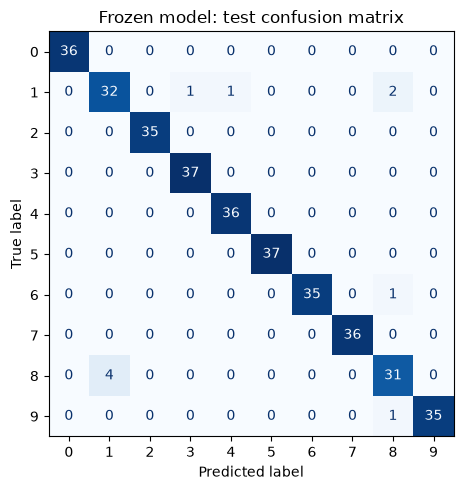

In [20]:
from sklearn.metrics import ConfusionMatrixDisplay
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y[test_idx], prediction, ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Frozen model: test confusion matrix")
plt.tight_layout()
plt.show()

<strong>运行后看哪里：</strong> 先定位一个非对角线格子，说清“真实是什么、误判为什么”。

<details><summary>展开检查答案</summary>

不是。通常是对角线正确数量较多，错误严重程度还取决于任务代价。

</details>

## 步骤21｜只看一个错例，提出可检验假设

错误位置先在测试子集内部，必须映射回原始索引。这里定位一个错例而不是堆满整排图。

<strong>先想一想：</strong> 看完错例再优化，能继续称这批样本为未见测试吗？

<!-- [ref:l2-wrong-count] -->

错例数： 10


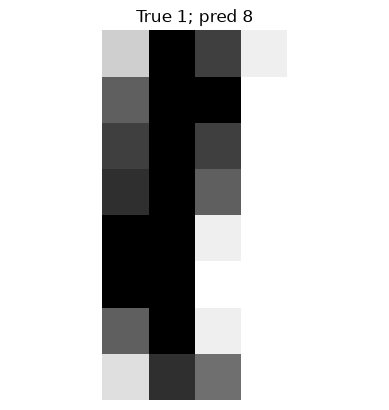

In [21]:
wrong = np.flatnonzero(prediction != y[test_idx])
print("错例数：", len(wrong))
if len(wrong):
    position = wrong[0]
    original_row = test_idx[position]
    plt.imshow(X[original_row].reshape(8, 8), cmap="gray_r")
    plt.title(f"True {y[original_row]}; pred {prediction[position]}")
    plt.axis("off")
    plt.show()

<strong>运行后看哪里：</strong> True为真实类别，pred为预测类别。先描述可观察形状，再提出原因假设，不要将猜测写成事实。

<details><summary>展开检查答案</summary>

不能。下一轮应重新设计开发和评价协议。

</details>

## 独立练习：解释一条完整的数据路径

不新增模型，画出从X到prediction的流程，标出每个fit看到了哪个集合；任选一段代码交给AI解释，再核查其说法是否正确。提交：数据流图、一个自己解释的参数、一处AI回答的核验记录。

<details><summary>教师参考：合格答案需要包含什么</summary>

先保留测试；在训练数据学习缩放和模型参数；用验证选择C；冻结后用开发集重训；测试只用于最终报告。API能跑通不等于协议正确，索引互斥不等于身份隔离。

</details>


## 步骤22｜课件图表导出（教师演示辅助）

以下图形与打印只为本讲课件提供可核查的素材：全部确定性生成，无随机成分；准确率数值与步骤9、16、17、19的实际输出一致。学生课后练习不需要运行本节。

<!-- [ref:l2-fig-digits-grid] -->

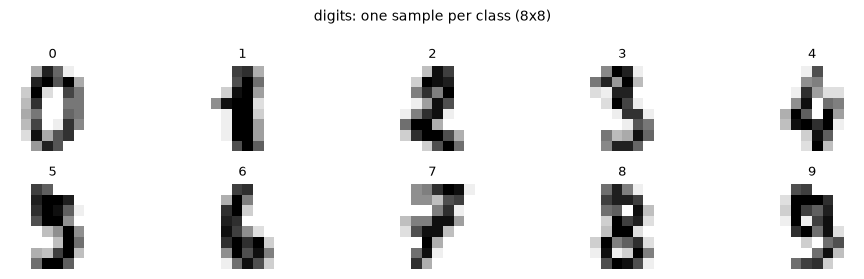

In [22]:
# 图1：0–9 每类取全集第一个样本，拼成 2×5 网格（确定性取样，无随机成分）
fig, axes = plt.subplots(2, 5, figsize=(10, 2.8))
for digit in range(10):
    ax = axes[digit // 5][digit % 5]
    first = np.flatnonzero(y == digit)[0]
    ax.imshow(X[first].reshape(8, 8), cmap="gray_r")
    ax.set_title(str(digit), fontsize=9)
    ax.axis("off")
fig.suptitle("digits: one sample per class (8x8)", fontsize=10)
fig.tight_layout()
plt.show()

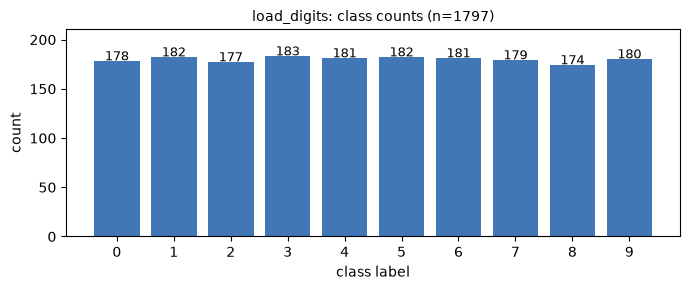

In [23]:
# [ref:l2-fig-class-count]
# 图2：全集 1797 条的类别计数柱状图（np.bincount 确定性统计）
counts = np.bincount(y)
fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(range(10), counts, color="#4177b7")
for digit, count in enumerate(counts):
    ax.text(digit, count + 1, str(count), ha="center", fontsize=9)
ax.set_xticks(range(10))
ax.set_ylim(0, counts.max() * 1.15)
ax.set_xlabel("class label")
ax.set_ylabel("count")
ax.set_title("load_digits: class counts (n=1797)", fontsize=10)
fig.tight_layout()
plt.show()

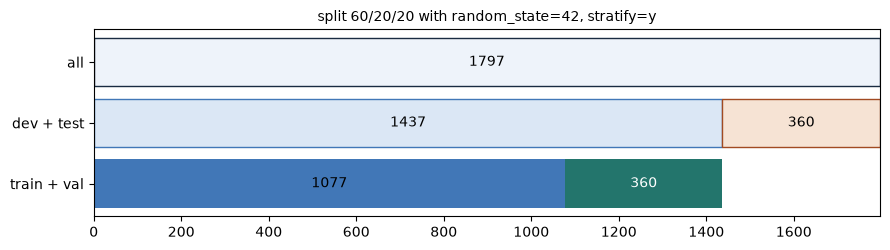

In [24]:
# 图3：1797 条样本的三块划分嵌套比例条（纯比例绘制，数字来自步骤4、5的打印输出）
total, dev_size, test_size = len(y), len(dev_idx), len(test_idx)
train_size, val_size = len(train_idx), len(val_idx)
fig, ax = plt.subplots(figsize=(9, 2.6))
ax.barh(0, total, color="#eef3fa", edgecolor="#192b41", label="all 1797")
ax.barh(1, dev_size, color="#dbe7f5", edgecolor="#4177b7", label="dev 1437")
ax.barh(1, test_size, left=dev_size, color="#f6e3d4", edgecolor="#a14a22", label="test 360")
ax.barh(2, train_size, color="#4177b7", label="train 1077")
ax.barh(2, val_size, left=train_size, color="#23756c", label="val 360")
for row, width in [(0, total), (1, dev_size), (2, train_size)]:
    ax.text(width / 2, row, str(width), va="center", ha="center", fontsize=10)
ax.text(dev_size + test_size / 2, 1, str(test_size), va="center", ha="center", fontsize=10)
ax.text(train_size + val_size / 2, 2, str(val_size), va="center", ha="center",
        color="white", fontsize=10)
ax.set_yticks([0, 1, 2], labels=["all", "dev + test", "train + val"])
ax.set_xlim(0, total)
ax.invert_yaxis()
ax.set_title("split 60/20/20 with random_state=42, stratify=y", fontsize=10)
fig.tight_layout()
plt.show()

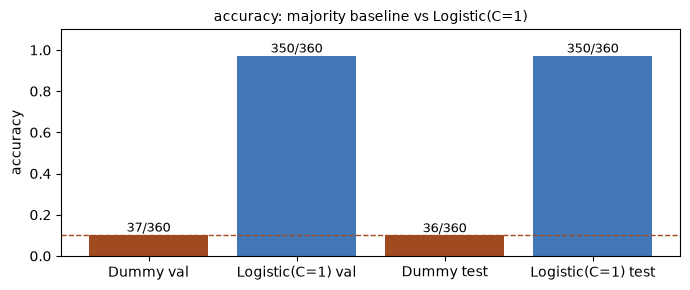

In [25]:
# [ref:l2-fig-accuracy]
# 图4：基线与 Logistic 回归的准确率对比（数值硬编码，取自步骤9/16/19已执行输出）
reported = [
    ("Dummy val", 37, 360),           # 步骤9：37/360，手算 0.1028
    ("Logistic(C=1) val", 350, 360),  # 步骤16：C 循环验证 0.9722
    ("Dummy test", 36, 360),          # 步骤22 下方打印：36/360
    ("Logistic(C=1) test", 350, 360), # 步骤19：测试 0.9722
]
names = [name for name, _, _ in reported]
accuracies = [correct / total for _, correct, total in reported]
fig, ax = plt.subplots(figsize=(7, 3))
bars = ax.bar(names, accuracies, color=['#a14a22', '#4177b7', '#a14a22', '#4177b7'])
for bar, (_, correct, total) in zip(bars, reported):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.015,
            f"{correct}/{total}", ha="center", fontsize=9)
ax.axhline(0.1, color="#a14a22", linestyle="--", linewidth=1)
ax.set_ylim(0, 1.1)
ax.set_ylabel("accuracy")
ax.set_title("accuracy: majority baseline vs Logistic(C=1)", fontsize=10)
fig.tight_layout()
plt.show()


In [26]:
# 证据打印：测试集多数类计数与两个模型的正确数（写课件前先实证，禁止未验证写数）
test_labels = y[test_idx]
print("测试集各类数量：", np.bincount(test_labels))
baseline_test_pred = final_baseline.predict(X[test_idx])
logistic_test_correct = int((prediction == test_labels).sum())
dummy_test_correct = int((baseline_test_pred == test_labels).sum())
print(f"Dummy 测试正确数：{dummy_test_correct}/{len(test_labels)}")
print(f"Logistic(C=1) 测试正确数：{logistic_test_correct}/{len(test_labels)}")

测试集各类数量： [36 36 35 37 36 37 36 36 35 36]
Dummy 测试正确数：36/360
Logistic(C=1) 测试正确数：350/360
